# Updated OpenCV + ToF Verification Notebook
This notebook is a non-destructive copy of main.ipynb with improved OpenCV detection and sensor verification logic.


# Read the existing .csv file

In [1]:
import pandas as pd
df = pd.read_csv("/content/fused_sensor_training_data.csv")

df_clean = df[df['ToF_Amplitude'] > 20].copy()

# Handle any missing values (NaNs)
df_clean = df_clean.dropna()

print(f"Original rows: {len(df)}, Cleaned row: {len(df_clean)}")

Original rows: 10000, Cleaned row: 9872


# Implementing random forest classifier for train the model

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import pickle
warnings.filterwarnings("ignore")

# Load your dataset
data = pd.read_csv("/content/fused_sensor_training_data.csv")


# Features: The data the model will learn from (e.g., Depth and position)
X = df_clean[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]

# Labels: The target category you want the model to predict
y = df_clean['Target_Label']
# Split 50% train / 50% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1 , random_state=42, stratify=y
)

# Train model
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(X_train, y_train)

# this is for prediction
y_pred = rf_classifier.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

# Sample prediction
sample = X_test.iloc[20:30]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[2].to_dict()
print(f"Sample Reading: {sample_dict}")
print(f"Predicted Label: {prediction[2]}")
print(f"Predicted Victim: {'Present' if prediction[2] == 'Victim' else 'Not Present'}")

with open('my_trained_tof_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
    print("Model is successfully converted in .pkl")

Accuracy: 0.93

Classification Report:
                precision    recall  f1-score   support

Heated Object       0.80      0.46      0.58       103
 Surroundings       1.00      1.00      1.00       484
       Victim       0.87      0.97      0.92       401

     accuracy                           0.93       988
    macro avg       0.89      0.81      0.83       988
 weighted avg       0.93      0.93      0.92       988

Sample Reading: {'Pixel_X': 279.0, 'Pixel_Y': 346.0, 'Depth_mm': 1903.4, 'ToF_Amplitude': 77.0}
Predicted Label: Victim
Predicted Victim: Present
Model is successfully converted in .pkl


In [3]:
import pandas as pd



# 1. Grab the 10 rows of features (X) and their true labels (y)
sample_X = X_test.iloc[40:50]
true_labels = y_test.iloc[40:50].values # .values converts it to a clean list

# 2. Ask the trained model to predict what these 10 items are
predicted_labels = rf_classifier.predict(sample_X)

# 3. Create a clean DataFrame to compare the results side-by-side
comparison_df = pd.DataFrame({
    'True Label': true_labels,
    'Model Prediction': predicted_labels
})

# 4. Add a column to easily see if the model got it right (True/False)
comparison_df['Correct?'] = comparison_df['True Label'] == comparison_df['Model Prediction']

# 5. Print the final comparison table
print(comparison_df)

      True Label Model Prediction  Correct?
0  Heated Object    Heated Object      True
1  Heated Object           Victim     False
2   Surroundings     Surroundings      True
3   Surroundings     Surroundings      True
4   Surroundings     Surroundings      True
5         Victim           Victim      True
6  Heated Object           Victim     False
7   Surroundings     Surroundings      True
8         Victim           Victim      True
9  Heated Object    Heated Object      True


1. Loading systems...
Image size (H,W): (259, 390)
Pixel_X range: 0 639
Pixel_Y range: 0 479
2. Scanning image for human shapes...
Raw detections: 3
After NMS: 3

Potential victim found at X:212, Y:112. Verifying sensors...
VERIFIED: Thermal and Depth signatures match a human!

Potential victim found at X:143, Y:63. Verifying sensors...
VERIFIED: Thermal and Depth signatures match a human!

Potential victim found at X:261, Y:41. Verifying sensors...
VERIFIED: Thermal and Depth signatures match a human!


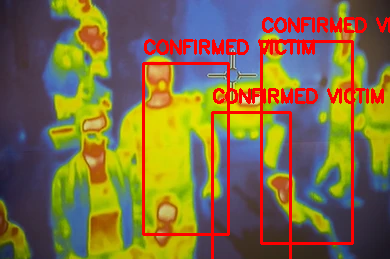

In [17]:
import cv2
import pickle
import pandas as pd
import joblib
import numpy as np
from google.colab.patches import cv2_imshow # Used to load your pre-trained Random Forest model
from google.colab import files
import os

# ==========================================
# STEP 1: LOAD YOUR PRE-TRAINED AI & DATA
# ==========================================
print("1. Loading systems...")

# Load the Random Forest model we trained earlier
# (Assuming you saved it. If not, you'd train it here first)
rf_model = joblib.load('my_trained_tof_model.pkl') 

# Load the CSV data for the current frame
sensor_data = pd.read_csv('/content/fused_sensor_training_data.csv')

# Load the visual image for the current frame
image_path = '/content/trial.png'
if not os.path.exists(image_path):
    print('Image not found at', image_path, '- please upload the image now.')
    uploaded = files.upload()
    image_path = next(iter(uploaded))

image = cv2.imread(image_path)

# ==========================================
# DEBUG: CHECK COORDINATE RANGES
# ==========================================
print("Image size (H,W):", image.shape[:2])
print("Pixel_X range:", sensor_data['Pixel_X'].min(), sensor_data['Pixel_X'].max())
print("Pixel_Y range:", sensor_data['Pixel_Y'].min(), sensor_data['Pixel_Y'].max())

# Optional: If your Pixel_X/Y are not in image scale, normalize them to image size
# Uncomment the block below if the ranges don't match image width/height
# h, w = image.shape[:2]
# sensor_w = sensor_data['Pixel_X'].max()
# sensor_h = sensor_data['Pixel_Y'].max()
# sensor_data['Pixel_X'] = (sensor_data['Pixel_X'] * (w / sensor_w)).astype(int)
# sensor_data['Pixel_Y'] = (sensor_data['Pixel_Y'] * (h / sensor_h)).astype(int)

# ==========================================
# STEP 2: RUN OPENCV (THE SPOTTER)
# ==========================================
print("2. Scanning image for human shapes...")
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Optimized HOG params for crowded/occluded scenes
# - Slight downscale for speed
# - Smaller stride and padding to improve recall
# - Lower hitThreshold to allow weaker matches
image_small = cv2.resize(image, None, fx=0.77, fy=0.90, interpolation=cv2.INTER_LINEAR)
boxes, weights = hog.detectMultiScale(
    image_small, 
    winStride=(4, 4), 
    padding=(8, 8), 
    scale=1.03,
    hitThreshold=-0.6)

print("Raw detections:", len(boxes))


boxes = [(int(x/0.85), int(y/0.85), int(w/0.85), int(h/0.85)) for (x, y, w, h) in boxes]
weights = [float(w) for w in weights] if len(weights) else []


def nms(rects, scores, iou_thresh=0.4):
    if len(rects) == 0:
        return []
    rects_np = np.array(rects)
    x1 = rects_np[:, 0]
    y1 = rects_np[:, 1]
    x2 = rects_np[:, 0] + rects_np[:, 2]
    y2 = rects_np[:, 1] + rects_np[:, 3]
    scores_np = np.array(scores) if len(scores) else np.ones(len(rects))

    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores_np.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(iou <= iou_thresh)[0]
        order = order[inds + 1]
    return keep

keep_idx = nms(boxes, weights, iou_thresh=0.45)
boxes = [boxes[i] for i in keep_idx]
print("After NMS:", len(boxes))


if len(boxes) > 0:
    for (x, y, w, h) in boxes:
        print(f"\nPotential victim found at X:{x}, Y:{y}. Verifying sensors...")
        
       
        box_data = sensor_data[
            (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
            (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
        ]
        
      
        if not box_data.empty:
            features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]
            predictions = rf_model.predict(features)

            
            human_pixel_count = (predictions == 'Victim').sum()

            if human_pixel_count > 10: 
                print("VERIFIED: Thermal and Depth signatures match a human!")
               
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                cv2.putText(image, 'CONFIRMED VICTIM', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            else:
                print("REJECTED: Shape detected, but thermal/depth says it is not human.")
        else:
            print("REJECTED: No matching sensor pixels inside this box.")
else:
    print("No shapes detected.")


cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
import cv2                      
import pickle                   
import pandas as pd            
import joblib                 
import numpy as np              
from google.colab.patches import cv2_imshow  
from google.colab import files               
import os                     


print("1. Loading systems...")


rf_model = joblib.load('my_trained_tof_model.pkl') 


sensor_data = pd.read_csv('/content/fused_sensor_training_data.csv')


image_path = '/content/data/3rd pic.jpg'


if not os.path.exists(image_path):
    print('Image not found at', image_path, '- please upload the image now.')
    uploaded = files.upload()
    image_path = next(iter(uploaded))   


image = cv2.imread(image_path)


print("Image size (H,W):", image.shape[:2])           
print("Pixel_X range:", sensor_data['Pixel_X'].min(), sensor_data['Pixel_X'].max())
print("Pixel_Y range:", sensor_data['Pixel_Y'].min(), sensor_data['Pixel_Y'].max())

# If sensor coords are not same size as image, you can scale them
# h, w = image.shape[:2]
# sensor_w = sensor_data['Pixel_X'].max()
# sensor_h = sensor_data['Pixel_Y'].max()
# sensor_data['Pixel_X'] = (sensor_data['Pixel_X'] * (w / sensor_w)).astype(int)
# sensor_data['Pixel_Y'] = (sensor_data['Pixel_Y'] * (h / sensor_h)).astype(int)


print("2. Scanning image for human shapes...")

hog = cv2.HOGDescriptor()                               
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())  

# Resize image smaller for faster detection
image_small = cv2.resize(image, None, fx=0.85, fy=0.85, interpolation=cv2.INTER_LINEAR)


boxes, weights = hog.detectMultiScale(
    image_small, 
    #winstride helps for jumps pixels to pixel , so i set it to 4,4 which is good for crowded scenes
    winStride=(4, 4), 
    padding=(8, 8), 
    scale=1.03,
    hitThreshold=-0.6)

print("Raw detections:", len(boxes))


boxes = [(int(x/0.85), int(y/0.85), int(w/0.85), int(h/0.85)) for (x, y, w, h) in boxes]
weights = [float(w) for w in weights] if len(weights) else []

#externally i add this section will help to merge overlapping boxes into one box using non maximu supression
def nms(rects, scores, iou_thresh=0.4):
    if len(rects) == 0:
        return []
    #this block converts the boxes into numpy arrays which makes HOG detection much faster and more efficient
    rects_np = np.array(rects)
    x1 = rects_np[:, 0]
    y1 = rects_np[:, 1]
    x2 = rects_np[:, 0] + rects_np[:, 2]
    y2 = rects_np[:, 1] + rects_np[:, 3]
    #if no scores given , it will assumes tht all boxes are equally confident
    scores_np = np.array(scores) if len(scores) else np.ones(len(rects))

    #will compute area
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores_np.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        #Find overlap region between the best box and all the other boxes.
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(iou <= iou_thresh)[0]
        order = order[inds + 1]
    #it will Return indices of boxes to keep
    return keep

keep_idx = nms(boxes, weights, iou_thresh=0.45)  
boxes = [boxes[i] for i in keep_idx]
print("After NMS:", len(boxes))


if len(boxes) > 0:
    for (x, y, w, h) in boxes:
        print(f"\nPotential victim found at X:{x}, Y:{y}. Verifying sensors...")

        
        box_data = sensor_data[
            (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
            (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
        ]

        
        if not box_data.empty:
            features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]
            predictions = rf_model.predict(features)

            
            human_pixel_count = (predictions == 'Victim').sum()

            if human_pixel_count > 10:
                print("VERIFIED: Thermal and Depth signatures match a human!")
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                cv2.putText(image, 'CONFIRMED VICTIM', (x, y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            else:
                print("REJECTED: Shape detected, but thermal/depth says it is not human.")
        else:
            print("REJECTED: No matching sensor pixels inside this box.")
else:
    print("No shapes detected.")

cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()


Exists: False
CWD: /content
Files in /content: ['/content/fused_sensor_training_data.csv', '/content/data', '/content/my_trained_tof_model.pkl', '/content/sample_data']
